In [72]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
# For one step reaction
y0 = {
    'S_1' : (1, 100),
    'S_2' : (1, 100),
    'S_3' : (0, 0),
    'S_4' : (0, 0),
    'S_out' : (0, 0),
}
ks = [2e3*1e-9, 2e7*1e-9]  # M^-1 s^-1 converted to nM^-1 s^-1

time_hours = 3 #hours
t_end = time_hours * 3600  # seconds

data_gen = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

batch_size = 36
batch = data_gen.generate_batch(batch_size)
norm = Normalize(max_concentration=torch.max(batch["c0"]))

ds = KineticDataset(batch, transform=norm)

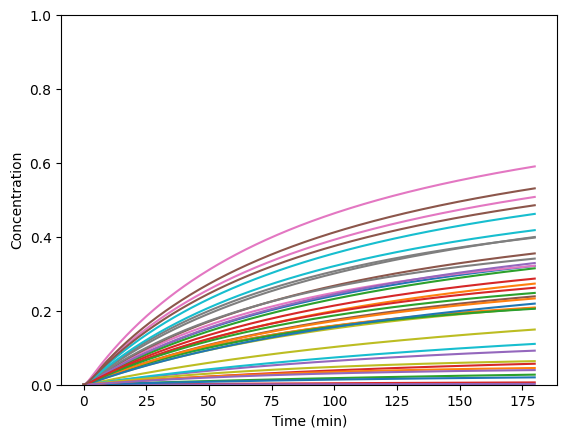

In [73]:
# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()

for i in range(batch_size):
    sample = ds[i]
    y = sample['y'].numpy()
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, 1)
plt.show()

In [74]:
# Get the data loaders ready
n_total = len(ds)
n_train = 30
n_test = 6
n_val = n_total - n_train - n_test


train_ds, test_ds, val_ds = torch.utils.data.random_split(
    ds, [n_train, n_test, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader, test_loader, val_loader = get_data_loaders(
    train_ds, test_ds, val_ds,
    batch_size=6
)

In [76]:
#global hyperparameters
base_ds = train_ds.dataset  # original KineticDataset
out_ind = base_ds.get_output_index()
out_ind = int(out_ind.item()) if torch.is_tensor(out_ind) else int(out_ind)
epochs = 500
learning_rate = 1e-2
norm_value = base_ds.transform.max_c0.item()

# 1 reaction

In [77]:
num_reactions = 1

## No regularization


### Known species experiment

In [78]:
# global constants pulled from the *base dataset*
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.148026
Epoch 11/500 | loss 0.037211
Epoch 21/500 | loss 0.024956
Epoch 31/500 | loss 0.022460
Epoch 41/500 | loss 0.021624
Epoch 51/500 | loss 0.020716
Epoch 61/500 | loss 0.020218
Epoch 71/500 | loss 0.018662
Epoch 81/500 | loss 0.017403
Epoch 91/500 | loss 0.016285
Epoch 101/500 | loss 0.014945
Epoch 111/500 | loss 0.013800
Epoch 121/500 | loss 0.012401
Epoch 131/500 | loss 0.011196
Epoch 141/500 | loss 0.009973
Epoch 151/500 | loss 0.008708
Epoch 161/500 | loss 0.007500
Epoch 171/500 | loss 0.006376
Epoch 181/500 | loss 0.005219
Epoch 191/500 | loss 0.004100
Epoch 201/500 | loss 0.003094
Epoch 211/500 | loss 0.002075
Epoch 221/500 | loss 0.001095
Epoch 231/500 | loss 0.002424
Epoch 241/500 | loss 0.000947
Epoch 251/500 | loss 0.001706
Epoch 261/500 | loss 0.005670
Epoch 271/500 | loss 0.001522
Epoch 281/500 | loss 0.000872
Epoch 291/500 | loss 0.000706
Epoch 301/500 | loss 0.001212
Epoch 311/500 | loss 0.000977
Epoch 321/500 | loss 0.001220
Epoch 331/500 | loss 

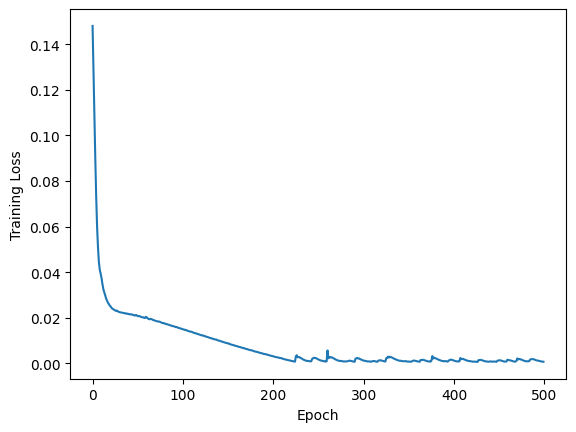

Learned reaction rates: [1973.1077]
Reaction stoiciometry
[[-9.8940176e-01]
 [-9.8940182e-01]
 [-3.1044983e-04]
 [ 9.8971230e-01]
 [ 9.8971230e-01]]


In [79]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

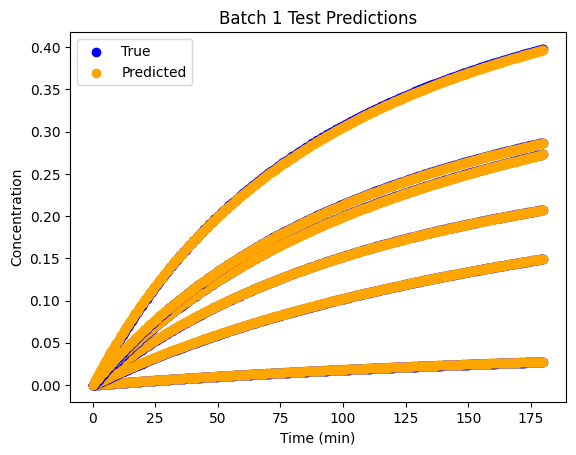

In [80]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

### all possible species with single atom counts

In [ ]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 1, 1, 0, 0, 1],  # Atom A
    [0, 1, 1, 0, 1, 0, 1],  # Atom B
    [0, 1, 1, 1, 0, 1, 0],  # Atom C
], dtype = int)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.752839
Epoch 11/500 | loss 0.238525
Epoch 21/500 | loss 0.126850
Epoch 31/500 | loss 0.123832
Epoch 41/500 | loss 0.135228
Epoch 51/500 | loss 0.188506
Epoch 61/500 | loss 0.082789
Epoch 71/500 | loss 0.092451
Epoch 81/500 | loss 0.091197
Epoch 91/500 | loss 0.043396
Epoch 101/500 | loss 0.071557
Epoch 111/500 | loss 0.072155
Epoch 121/500 | loss 0.048554
Epoch 131/500 | loss 0.079275
Epoch 141/500 | loss 0.032963
Epoch 151/500 | loss 0.044643
Epoch 161/500 | loss 0.057775
Epoch 171/500 | loss 0.055307
Epoch 181/500 | loss 0.062960
Epoch 191/500 | loss 0.096225
Epoch 201/500 | loss 0.059770
Epoch 211/500 | loss 0.139975
Epoch 221/500 | loss 0.108444
Epoch 231/500 | loss 0.095950
Epoch 241/500 | loss 0.063801
Epoch 251/500 | loss 0.073764
Epoch 261/500 | loss 0.031462
Epoch 271/500 | loss 0.068255
Epoch 281/500 | loss 0.041267
Epoch 291/500 | loss 0.088033
Epoch 301/500 | loss 0.077212
Epoch 311/500 | loss 0.164094
Epoch 321/500 | loss 0.063225
Epoch 331/500 | loss 

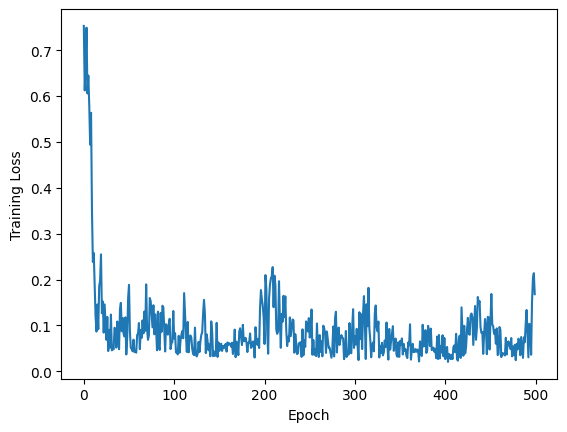

Learned reaction rates: [395549.5]
Reaction stoiciometry
[[-0.60333073]
 [-0.81863266]
 [ 0.09972667]
 [ 0.5835057 ]
 [ 0.7988076 ]
 [ 0.13540033]
 [-0.07990154]]


In [ ]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

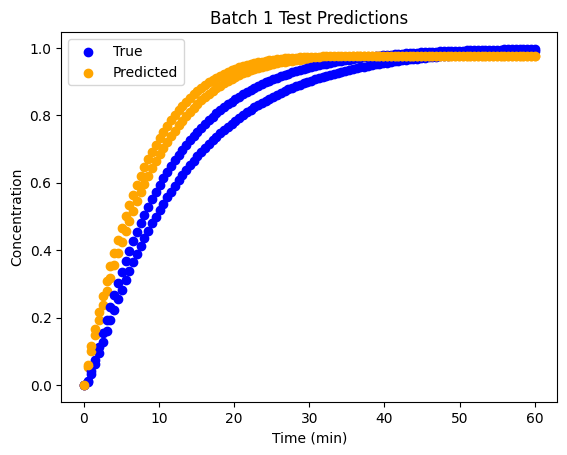

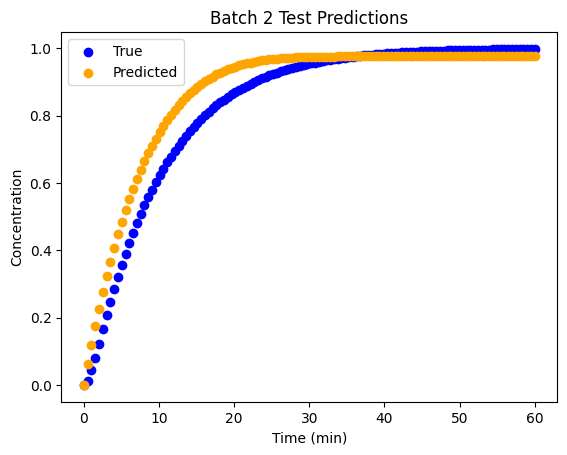

In [ ]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## With L1 regularization

In [39]:
lambda_l1 = 1e-4  

### Known species experiment

In [40]:
# global constants pulled from the *base dataset*
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.755939
Epoch 11/500 | loss 0.745637
Epoch 21/500 | loss 0.728537
Epoch 31/500 | loss 0.617497
Epoch 41/500 | loss 0.570307
Epoch 51/500 | loss 0.442299
Epoch 61/500 | loss 0.325722
Epoch 71/500 | loss 0.147381
Epoch 81/500 | loss 0.092651
Epoch 91/500 | loss 0.050190
Epoch 101/500 | loss 0.044986
Epoch 111/500 | loss 0.045668
Epoch 121/500 | loss 0.084853
Epoch 131/500 | loss 0.056591
Epoch 141/500 | loss 0.077736
Epoch 151/500 | loss 0.052113
Epoch 161/500 | loss 0.089382
Epoch 171/500 | loss 0.050051
Epoch 181/500 | loss 0.080484
Epoch 191/500 | loss 0.075928
Epoch 201/500 | loss 0.059580
Epoch 211/500 | loss 0.096347
Epoch 221/500 | loss 0.060341
Epoch 231/500 | loss 0.078159
Epoch 241/500 | loss 0.066100
Epoch 251/500 | loss 0.085721
Epoch 261/500 | loss 0.075317
Epoch 271/500 | loss 0.072683
Epoch 281/500 | loss 0.095390
Epoch 291/500 | loss 0.068512
Epoch 301/500 | loss 0.059938
Epoch 311/500 | loss 0.082708
Epoch 321/500 | loss 0.049915
Epoch 331/500 | loss 

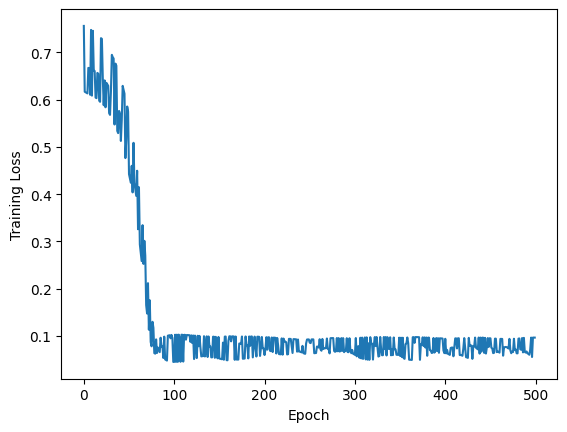

Learned reaction rates: [297277.12]
Reaction stoiciometry
[[-0.31736222]
 [-0.31736225]
 [ 0.01843168]
 [ 0.2989306 ]
 [ 0.2989306 ]]


In [41]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

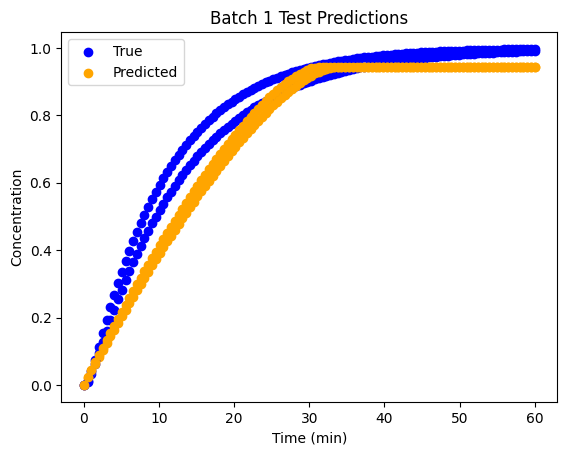

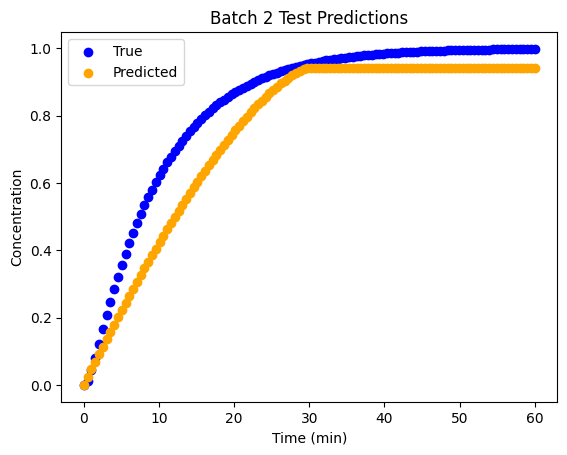

In [42]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

### all possible species with single atom counts

In [ ]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 1, 1, 0, 0, 1],  # Atom A
    [0, 1, 1, 0, 1, 0, 1],  # Atom B
    [0, 1, 1, 1, 0, 1, 0],  # Atom C
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.668601
Epoch 11/500 | loss 0.401095
Epoch 21/500 | loss 0.232508
Epoch 31/500 | loss 0.127210
Epoch 41/500 | loss 0.060366
Epoch 51/500 | loss 0.183247
Epoch 61/500 | loss 0.050848
Epoch 71/500 | loss 0.123800
Epoch 81/500 | loss 0.157508
Epoch 91/500 | loss 0.065769
Epoch 101/500 | loss 0.073770
Epoch 111/500 | loss 0.041235
Epoch 121/500 | loss 0.039651
Epoch 131/500 | loss 0.097349
Epoch 141/500 | loss 0.033663
Epoch 151/500 | loss 0.075361
Epoch 161/500 | loss 0.070456
Epoch 171/500 | loss 0.029652
Epoch 181/500 | loss 0.031166
Epoch 191/500 | loss 0.159013
Epoch 201/500 | loss 0.179381
Epoch 211/500 | loss 0.050527
Epoch 221/500 | loss 0.051636
Epoch 231/500 | loss 0.045158
Epoch 241/500 | loss 0.045231
Epoch 251/500 | loss 0.029055
Epoch 261/500 | loss 0.106249
Epoch 271/500 | loss 0.052832
Epoch 281/500 | loss 0.128220
Epoch 291/500 | loss 0.029223
Epoch 301/500 | loss 0.070381
Epoch 311/500 | loss 0.051799
Epoch 321/500 | loss 0.069533
Epoch 331/500 | loss 

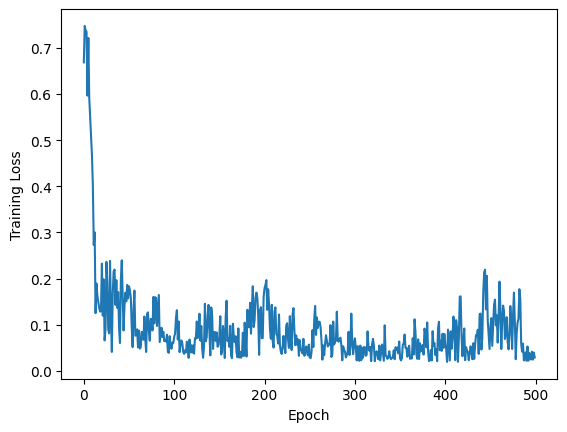

Learned reaction rates: [487248.8]
Reaction stoichiometry
[[-0.69812155]
 [-0.7683414 ]
 [-0.11631817]
 [ 0.6703864 ]
 [ 0.7406064 ]
 [ 0.21427321]
 [ 0.14405325]]


In [ ]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoichiometry')
print(-1*model.nu().detach().numpy())

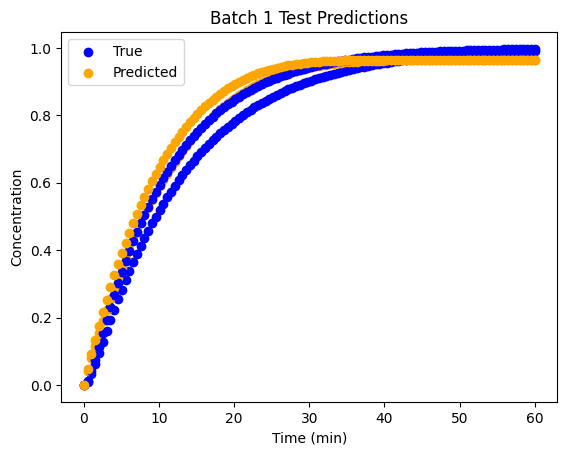

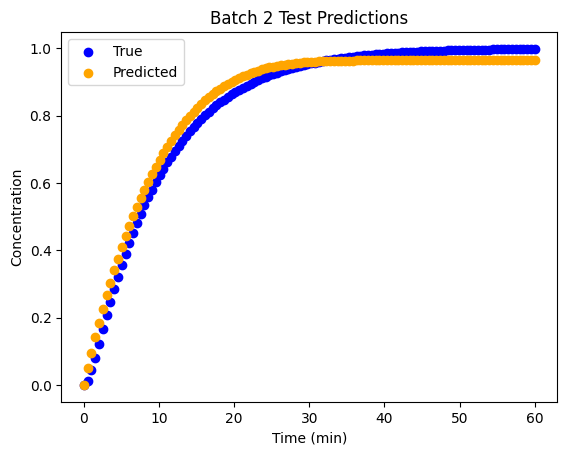

In [ ]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

# 2 reaction

In [81]:
num_reactions = 2

## No regularization


### Known species experiment

In [83]:
# global constants pulled from the *base dataset*
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.135157
Epoch 11/500 | loss 0.028141
Epoch 21/500 | loss 0.025974
Epoch 31/500 | loss 0.025443
Epoch 41/500 | loss 0.025111
Epoch 51/500 | loss 0.024541
Epoch 61/500 | loss 0.023804
Epoch 71/500 | loss 0.023360
Epoch 81/500 | loss 0.022560
Epoch 91/500 | loss 0.021593
Epoch 101/500 | loss 0.020173
Epoch 111/500 | loss 0.018957
Epoch 121/500 | loss 0.017316
Epoch 131/500 | loss 0.015700
Epoch 141/500 | loss 0.014185
Epoch 151/500 | loss 0.012452
Epoch 161/500 | loss 0.010765
Epoch 171/500 | loss 0.009233
Epoch 181/500 | loss 0.007641
Epoch 191/500 | loss 0.006257
Epoch 201/500 | loss 0.004703
Epoch 211/500 | loss 0.003484
Epoch 221/500 | loss 0.002237
Epoch 231/500 | loss 0.001384
Epoch 241/500 | loss 0.001128
Epoch 251/500 | loss 0.001311
Epoch 261/500 | loss 0.002196
Epoch 271/500 | loss 0.001249
Epoch 281/500 | loss 0.001321
Epoch 291/500 | loss 0.000846
Epoch 301/500 | loss 0.001610
Epoch 311/500 | loss 0.000862
Epoch 321/500 | loss 0.000683
Epoch 331/500 | loss 

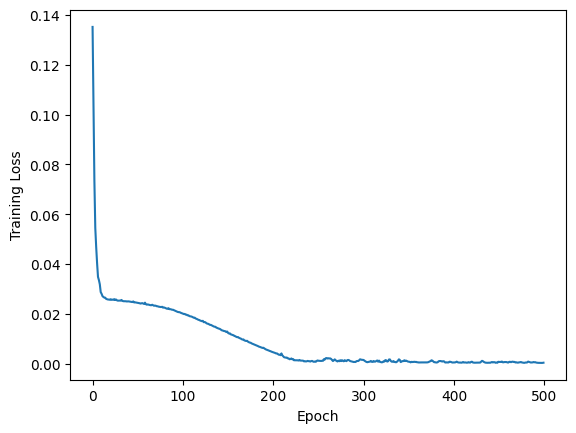

Learned reaction rates: [2228.1226   249.96841]
Reaction stoiciometry
[[-1.0213666  -0.63188964]
 [-1.0213667  -0.6318897 ]
 [-0.03306081  0.26466528]
 [ 1.0544275   0.36722443]
 [ 1.0544275   0.36722443]]


In [84]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

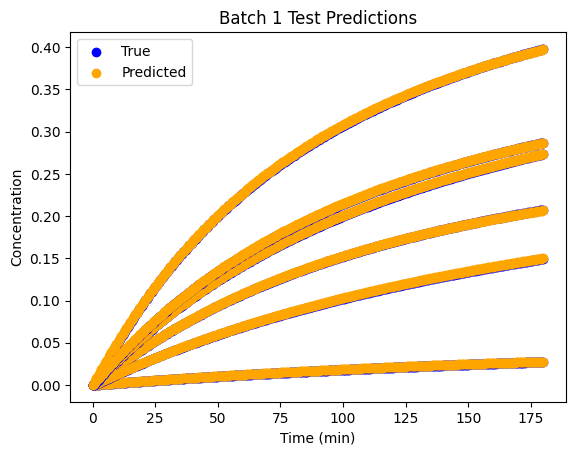

In [85]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

### all possible species with single atom counts

In [9]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 1, 1, 0, 0, 1],  # Atom A
    [0, 1, 1, 0, 1, 0, 1],  # Atom B
    [0, 1, 1, 1, 0, 1, 0],  # Atom C
], dtype = int)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.670984
Epoch 11/500 | loss 0.157844
Epoch 21/500 | loss 0.068512


KeyboardInterrupt: 

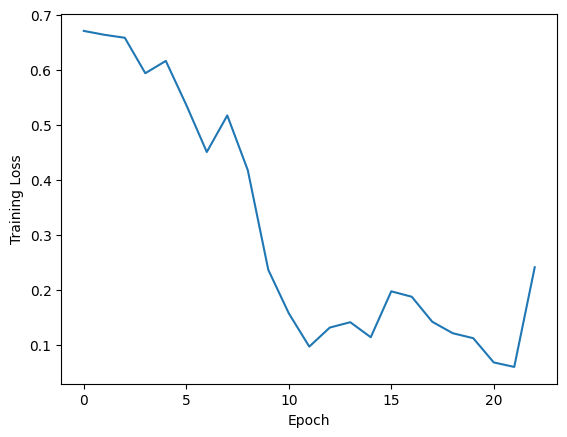

Learned reaction rates: [378267.62 306135.7 ]
Reaction stoiciometry
[[-0.2409805  -0.28139588]
 [-0.40992105 -0.43909645]
 [ 0.11150268  0.03420939]
 [ 0.33871582  0.24203514]
 [ 0.5076564   0.3997357 ]
 [-0.04029748  0.1628519 ]
 [-0.20923802  0.00515134]]


In [10]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

In [11]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

KeyboardInterrupt: 

## With L1 regularization

In [12]:
lambda_l1 = 1e-4  

### Known species experiment

In [13]:
# global constants pulled from the *base dataset*
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.612500
Epoch 11/500 | loss 0.150663
Epoch 21/500 | loss 0.183702
Epoch 31/500 | loss 0.147775
Epoch 41/500 | loss 0.119088
Epoch 51/500 | loss 0.060008
Epoch 61/500 | loss 0.067657
Epoch 71/500 | loss 0.123812
Epoch 81/500 | loss 0.132448
Epoch 91/500 | loss 0.067069


KeyboardInterrupt: 

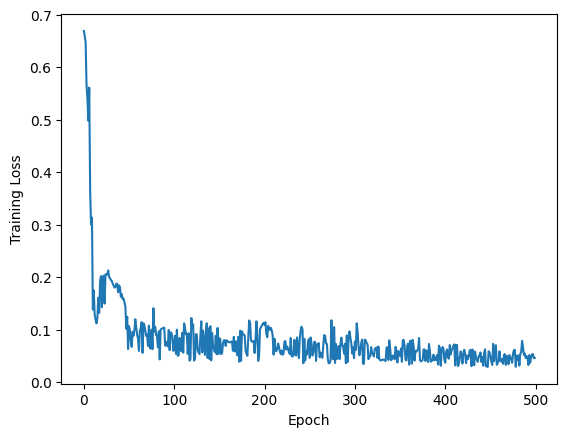

Learned reaction rates: [34178.082]
Reaction stoiciometry
[[-0.5718761 ]
 [-0.57187617]
 [ 0.01160976]
 [ 0.5602664 ]
 [ 0.5602663 ]]


In [90]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

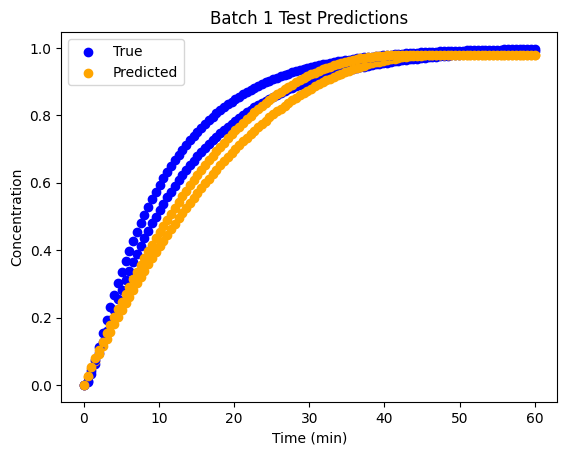

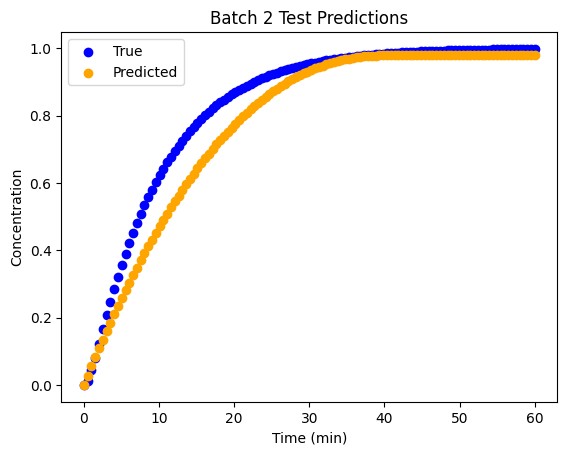

In [91]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

### all possible species with single atom counts

In [92]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 1, 1, 0, 0, 1],  # Atom A
    [0, 1, 1, 0, 1, 0, 1],  # Atom B
    [0, 1, 1, 1, 0, 1, 0],  # Atom C
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.668601
Epoch 11/500 | loss 0.401095
Epoch 21/500 | loss 0.232508
Epoch 31/500 | loss 0.127210
Epoch 41/500 | loss 0.060366
Epoch 51/500 | loss 0.183247
Epoch 61/500 | loss 0.050848
Epoch 71/500 | loss 0.123800
Epoch 81/500 | loss 0.157508
Epoch 91/500 | loss 0.065769
Epoch 101/500 | loss 0.073770
Epoch 111/500 | loss 0.041235
Epoch 121/500 | loss 0.039651
Epoch 131/500 | loss 0.097349
Epoch 141/500 | loss 0.033663
Epoch 151/500 | loss 0.075361
Epoch 161/500 | loss 0.070456
Epoch 171/500 | loss 0.029652
Epoch 181/500 | loss 0.031166
Epoch 191/500 | loss 0.159013
Epoch 201/500 | loss 0.179381
Epoch 211/500 | loss 0.050527
Epoch 221/500 | loss 0.051636
Epoch 231/500 | loss 0.045158
Epoch 241/500 | loss 0.045231
Epoch 251/500 | loss 0.029055
Epoch 261/500 | loss 0.106249
Epoch 271/500 | loss 0.052832
Epoch 281/500 | loss 0.128220
Epoch 291/500 | loss 0.029223
Epoch 301/500 | loss 0.070381
Epoch 311/500 | loss 0.051799
Epoch 321/500 | loss 0.069533
Epoch 331/500 | loss 

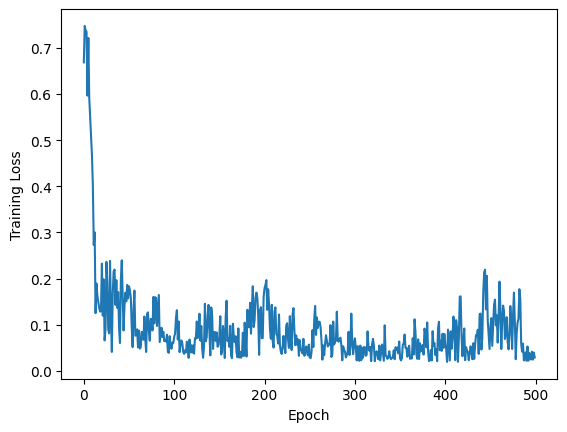

Learned reaction rates: [487248.8]
Reaction stoichiometry
[[-0.69812155]
 [-0.7683414 ]
 [-0.11631817]
 [ 0.6703864 ]
 [ 0.7406064 ]
 [ 0.21427321]
 [ 0.14405325]]


In [93]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoichiometry')
print(-1*model.nu().detach().numpy())

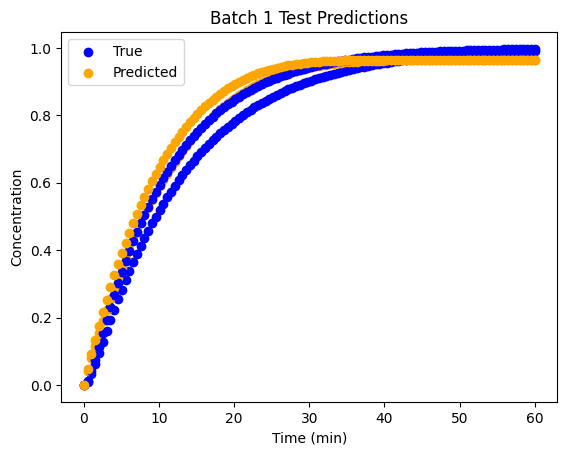

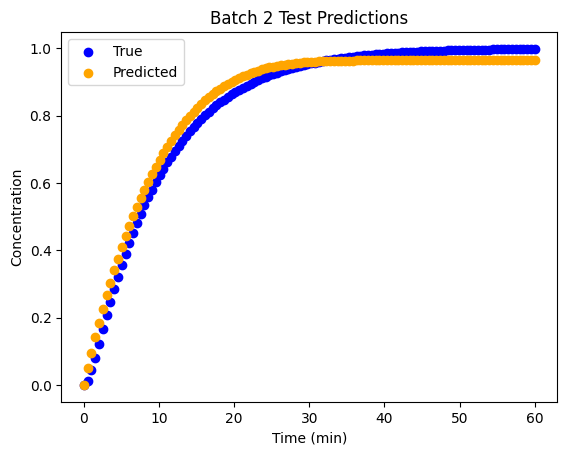

In [94]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()